Resumo — 26 células (0 a 25)   
Célula | Conteúdo   
0.	Instalação  
1.	Imports
2.	Carregar CSV
3.	Pipeline: filtro + NaN + encoding + AGREGAÇÃO
4.	Visualização dos dados
5.	Separar X/y + Normalização
6.	Divisão treino/teste
7.	Função avaliar_modelo()
8.	Regressão Linear Múltipla
9.	Árvore de Regressão
10.	Floresta Aleatória
11.	SVR (com OHE aplicado)
12.	Gradient Boosting
13.	KNN Regressor (NOVO!)
14.	Ranking comparativo
15.	Gráfico Real vs Predito
16.	Gráfico de barras
17.	Preparação projeções futuras
18.	Treinar modelos para projeção
19.	Tabela de projeções (10-500 anos)
20.	Gráfico histórico + projeções
21.	Gráfico barras agrupadas (futuro)
22.	Gráfico variação percentual
23.	Gráfico por setor (área empilhada)
24.	Gráfico curto prazo (50 anos)
25.	Resumo final do projeto

In [ ]:
# Célula 0 — Instalar bibliotecas necessárias
!pip install scikit-learn

In [19]:
# Célula 1 — Todos os imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import warnings
warnings.filterwarnings("ignore")

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


In [20]:
# Célula 2 — Carregar dados
df_raw = pd.read_csv("br_seeg_emissoes_brasil.csv")
print(f"Dataset original: {df_raw.shape}")
print(f"\nValores únicos de 'gas': {df_raw['gas'].unique()}")
df_raw.head()

Dataset original: (454850, 12)

Valores únicos de 'gas': ['CH4 (t)' 'CO2e (t) GTP-AR2' 'CO2e (t) GTP-AR4' 'CO2e (t) GTP-AR5'
 'CO2e (t) GWP-AR2' 'CO2e (t) GWP-AR4' 'CO2e (t) GWP-AR5' 'N2O (t)'
 'CO (t)' 'NOX (t)' 'CO2 (t)' 'COVNM (t)' 'NOx (t)' 'HFC-125 (t)'
 'HFC-134a (t)' 'HFC-143a (t)' 'HFC-152a (t)' 'HFC-23 (t)' 'HFC-32 (t)'
 'C2F6 (t)' 'CF4 (t)' 'SF6 (t)']


,ano,nivel_1,nivel_2,nivel_3,nivel_4,nivel_5,nivel_6,tipo_emissao,gas,atividade_economica,produto,emissao
0,1970,Agropecuária,Cultivo do Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),NaN,NaN,230462.17
1,1971,Agropecuária,Cultivo do Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),NaN,NaN,226016.30
2,1972,Agropecuária,Cultivo do Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),NaN,NaN,220101.20
3,1973,Agropecuária,Cultivo do Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),NaN,NaN,214195.56
4,1974,Agropecuária,Cultivo do Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),NaN,NaN,186862.84


In [ ]:
# Célula 3 — Pipeline de preparação dos dados
'''
    MUDANÇA PRINCIPAL em relação à versão anterior:
    
    Antes: usávamos cada linha individualmente (30795 linhas)
        → cada linha era um sub-setor específico
        → modelos não conseguiam aprender (R² ≈ 0)
    
    Agora: AGREGAMOS as emissões por ANO e SETOR
        → emissão total de CO2 por setor por ano
        → dados mais limpos e com padrão temporal claro
    
    Também criamos uma versão TOTAL (soma de todos os setores)
    para fazer as projeções futuras.
'''

# --- Passo 1: Selecionar colunas ---
df = df_raw[["ano", "nivel_1", "gas", "emissao"]].copy()
print(f"1) Seleção de colunas: {df.shape}")

# --- Passo 2: Filtrar CO2 ---
df = df[df["gas"] == "CO2 (t)"].copy()
print(f"2) Filtro CO2 (t): {df.shape}")

# --- Passo 3: Verificar nulos ---
print(f"\n3) Valores nulos:")
print(df.isnull().sum())

# --- Passo 4: Remover nulos em emissao ---
df = df.dropna(subset=["emissao"])
print(f"\n4) Após remover NaN: {df.shape}")

# --- Passo 5: Remover coluna gas ---
df = df.drop(columns=["gas"])

# --- Passo 6: AGREGAR emissões por ano e setor ---
#     ESTA É A MUDANÇA CHAVE!
#     Somamos todas as emissões de CO2 de cada setor por ano
df_setor = df.groupby(["ano", "nivel_1"])["emissao"].sum().reset_index()
print(f"\n5) Emissões agregadas por ano+setor: {df_setor.shape}")
print(f"   Setores: {df_setor['nivel_1'].unique()}")

# --- Passo 7: Criar dataset TOTAL (soma de todos os setores por ano) ---
#     Este será usado para as PROJEÇÕES FUTURAS
df_total = df.groupby("ano")["emissao"].sum().reset_index()
df_total.columns = ["ano", "emissao_total"]
print(f"\n6) Emissões totais por ano: {df_total.shape}")
print(f"   Anos: {df_total['ano'].min()} a {df_total['ano'].max()}")

# --- Passo 8: One-Hot Encoding no dataset por setor ---
df_modelo = pd.get_dummies(df_setor, columns=["nivel_1"], drop_first=True, dtype=int)
print(f"\n7) Após One-Hot Encoding: {df_modelo.shape}")
print(f"   Colunas: {list(df_modelo.columns)}")

# --- Verificação ---
print(f"\n{'->x<-'*10}")
print(f"   Dados prontos!")
print(f"   Dataset modelo (por setor): {df_modelo.shape}")
print(f"   Dataset total (projeções):  {df_total.shape}")
print(f"{'->x<-'*10}")

df_modelo.head(10)


1) Seleção de colunas: (454850, 4)
2) Filtro CO2 (t): (37550, 4)

3) Valores nulos:
ano           0
nivel_1       0
gas           0
emissao    6755
dtype: int64

4) Após remover NaN: (30795, 4)

5) Emissões agregadas por ano+setor: (250, 3)
   Setores: ['Agropecuária' 'Energia' 'Mudança de Uso da Terra e Floresta'
 'Processos Industriais' 'Resíduos ']

6) Emissões totais por ano: (50, 2)
   Anos: 1970 a 2019

7) Após One-Hot Encoding: (250, 6)
   Colunas: ['ano', 'emissao', 'nivel_1_Energia', 'nivel_1_Mudança de Uso da Terra e Floresta', 'nivel_1_Processos Industriais', 'nivel_1_Resíduos ']

->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
   Dados prontos!
   Dataset modelo (por setor): (250, 6)
   Dataset total (projeções):  (50, 2)
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-


,ano,emissao,nivel_1_Energia,nivel_1_Mudança de Uso da Terra e Floresta,nivel_1_Processos Industriais,nivel_1_Resíduos
0,1970,9.716176e+05,0,0,0,0
1,1970,7.632403e+07,1,0,0,0
2,1970,0.000000e+00,0,1,0,0
3,1970,1.131884e+07,0,0,1,0
4,1970,1.488171e+05,0,0,0,1
5,1971,1.393503e+06,0,0,0,0
6,1971,8.652302e+07,1,0,0,0
7,1971,0.000000e+00,0,1,0,0
8,1971,1.182835e+07,0,0,1,0
9,1971,1.448152e+05,0,0,0,1


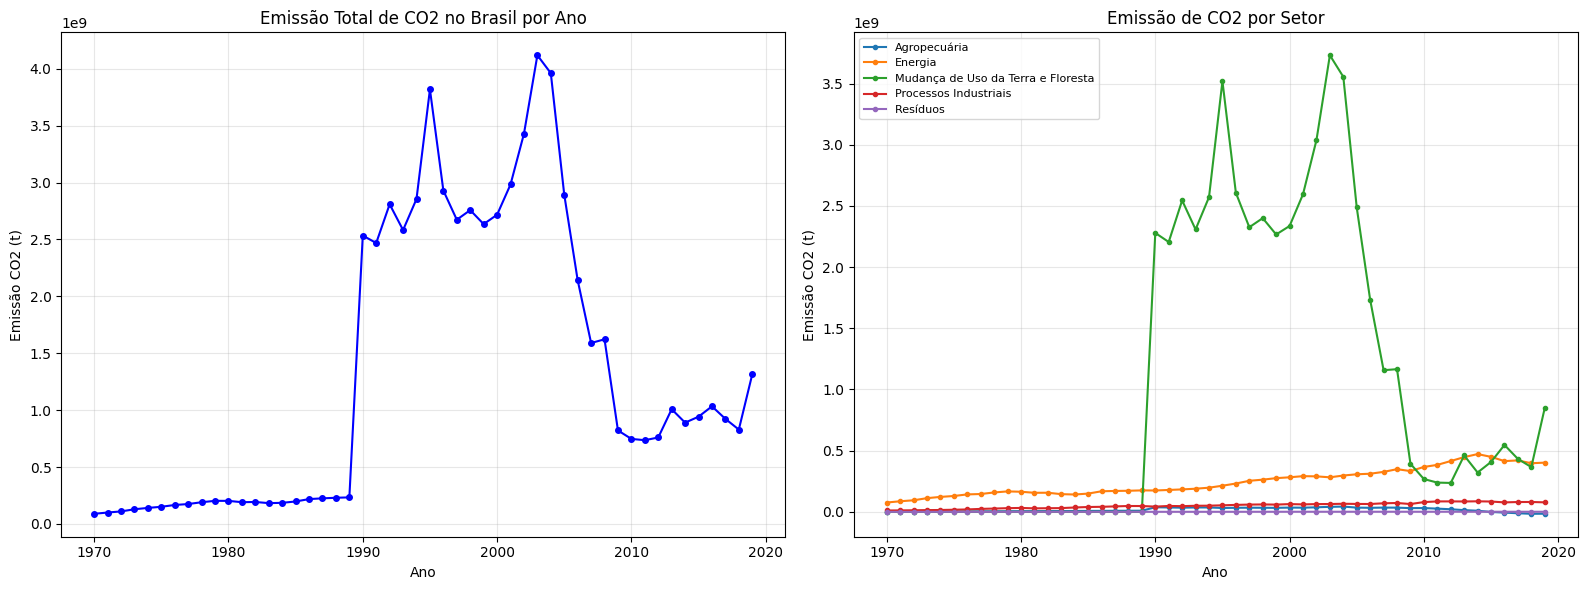

Observe os padrões temporais — isso é o que os modelos vão aprender!


In [37]:
# Célula 4 — Visualizar dados antes de modelar
'''
    Sempre bom visualizar os dados antes de treinar modelos.
    Isso ajuda a entender padrões e verificar se os dados
    fazem sentido.
'''

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Emissão total por ano
axes[0].plot(df_total["ano"], df_total["emissao_total"], "b-o", markersize=4)
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Emissão CO2 (t)")
axes[0].set_title("Emissão Total de CO2 no Brasil por Ano")
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Emissão por setor
for setor in df_setor["nivel_1"].unique():
    dados = df_setor[df_setor["nivel_1"] == setor]
    axes[1].plot(dados["ano"], dados["emissao"], "-o", markersize=3, label=setor)

axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Emissão CO2 (t)")
axes[1].set_title("Emissão de CO2 por Setor")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observe os padrões temporais — isso é o que os modelos vão aprender!")


In [38]:
# Célula 5 — Separar X e y + Normalização
'''
    Separamos features (X) e target (y) do dataset por setor.
    Depois normalizamos tudo para [0, 1].
'''

# Separar
X = df_modelo.drop(columns=["emissao"])
y = df_modelo["emissao"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {list(X.columns)}")

# Normalizar X
scaler_X = MinMaxScaler()
X = pd.DataFrame(
    scaler_X.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Normalizar y
scaler_y = MinMaxScaler()
y = pd.Series(
    scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten(),
    index=y.index,
    name="emissao"
)

# Verificações
assert X.shape[0] == y.shape[0], "❌ X e y com tamanhos diferentes!"
assert y.shape[0] > 0, "❌ y está vazio!"

print(f"\nX range: [{X.min().min():.4f}, {X.max().max():.4f}]")
print(f"y range: [{y.min():.4f}, {y.max():.4f}]")
print(f"\n{X.shape[0]} amostras, {X.shape[1]} features — prontos!")


X shape: (250, 5)
y shape: (250,)
Features: ['ano', 'nivel_1_Energia', 'nivel_1_Mudança de Uso da Terra e Floresta', 'nivel_1_Processos Industriais', 'nivel_1_Resíduos ']

X range: [0.0000, 1.0000]
y range: [0.0000, 1.0000]

250 amostras, 5 features — prontos!


In [39]:
# Célula 6 — Divisão treino/teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Treino: X={X_train.shape}, y={y_train.shape}")
print(f"Teste:  X={X_test.shape},  y={y_test.shape}")
print(f"\nDivisão 80/20 concluída!")


Treino: X=(200, 5), y=(200,)
Teste:  X=(50, 5),  y=(50,)

Divisão 80/20 concluída!


In [40]:
# Célula 7 — Função de avaliação (atualizada)

def avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test):
    """Treina o modelo, faz predições e exibe métricas."""
    
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    print(f"{'->x<-'*10}")
    print(f"  {nome}")
    print(f"{'->x<-'*10}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  R²:   {r2:.6f}")
    
    # Interpretar o R²
    if r2 >= 0.9:
        print(f"  → Excelente! 🟢")
    elif r2 >= 0.7:
        print(f"  → Bom 🟡")
    elif r2 >= 0.5:
        print(f"  → Razoável 🟠")
    else:
        print(f"  → Fraco 🔴")
    print()
    
    return {
        "nome": nome,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "y_pred": y_pred,
        "modelo": modelo
    }

print("Função avaliar_modelo() definida!")


Função avaliar_modelo() definida!


In [41]:
# Célula 8 — Modelo 1: Regressão Linear Múltipla (MLR)
'''
    Encontra a melhor combinação linear das features.
    y = b0 + b1*x1 + b2*x2 + ... + bn*xn
    
    Simples e rápido, mas assume relação LINEAR entre
    as variáveis — pode não capturar padrões complexos.
'''

res_mlr = avaliar_modelo(
    "Regressão Linear Múltipla",
    LinearRegression(),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  Regressão Linear Múltipla
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.064652
  RMSE: 0.118798
  R²:   0.425449
  → Fraco 🔴



In [42]:
# Célula 9 — Modelo 2: Árvore de Regressão
'''
    Divide os dados em regiões usando regras de decisão.
    Simples e interpretável, mas pode overfittar (decorar
    os dados de treino sem generalizar).
'''

res_arvore = avaliar_modelo(
    "Árvore de Regressão",
    DecisionTreeRegressor(random_state=42, max_depth=10),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  Árvore de Regressão
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.016422
  RMSE: 0.054950
  R²:   0.877074
  → Bom 🟡



In [43]:
# Célula 10 — Modelo 3: Floresta Aleatória de Regressão
'''
    Combina várias árvores de decisão (ensemble).
    Cada árvore vê uma parte aleatória dos dados.
    O resultado final é a MÉDIA das predições de todas as árvores.
    Reduz o overfitting em relação a uma árvore só.
'''

res_floresta = avaliar_modelo(
    "Floresta Aleatória",
    RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  Floresta Aleatória
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.013291
  RMSE: 0.037629
  R²:   0.942356
  → Excelente! 🟢



In [44]:
# Célula 11 — Modelo 4: SVR (Support Vector Regression)
'''
    Encontra um hiperplano que melhor se ajusta aos dados
    dentro de uma margem de tolerância (epsilon).
    
    Usa o kernel RBF (Radial Basis Function) que permite
    capturar relações não-lineares.
    
    MUITO sensível à escala — por isso normalizamos antes.
    
    One-Hot Encoding é necessário para SVR porque ele não
    aceita variáveis categóricas — precisa de tudo numérico.
'''

res_svr = avaliar_modelo(
    "SVR (Support Vector Regression)",
    SVR(kernel="rbf", C=10.0, epsilon=0.01, gamma="scale"),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  SVR (Support Vector Regression)
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.038338
  RMSE: 0.095781
  R²:   0.626521
  → Razoável 🟠



In [45]:
# Célula 12 — Modelo 5: Gradient Boosting Regression
'''
    Constrói árvores SEQUENCIALMENTE — cada nova árvore
    corrige os erros da anterior (boosting).
    Geralmente um dos modelos mais precisos.
'''

res_gbr = avaliar_modelo(
    "Gradient Boosting",
    GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  Gradient Boosting
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.016510
  RMSE: 0.054834
  R²:   0.877592
  → Bom 🟡



In [46]:
# Célula 13 — Modelo 6: KNN Regressor (NOVO!)
'''
    K-Nearest Neighbors Regression.
    Para prever um valor, olha os K vizinhos mais próximos
    no espaço das features e calcula a média dos seus valores.
    
    Simples e intuitivo. Funciona bem quando dados similares
    têm valores de emissão similares.
'''

res_knn = avaliar_modelo(
    "KNN Regressor",
    KNeighborsRegressor(n_neighbors=5, weights="distance"),
    X_train, X_test, y_train, y_test
)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  KNN Regressor
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  MAE:  0.012101
  RMSE: 0.043621
  R²:   0.922536
  → Excelente! 🟢



In [50]:
# Célula 14 — Ranking comparativo dos modelos

todos_resultados = [res_mlr, res_arvore, res_floresta, res_svr, res_gbr, res_knn]

resultados = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["y_pred", "modelo"]}
    for r in todos_resultados
])

# Ordenar pelo R² (maior = melhor)
resultados = resultados.sort_values("R2", ascending=False).reset_index(drop=True)

print("->x<-" * 15)
print("  RANKING DOS MODELOS (ordenado por R²)")
print("->x<-" * 15)
print(resultados.to_string(index=False))
print("->x<-" * 15)


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  RANKING DOS MODELOS (ordenado por R²)
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
                           nome      MAE     RMSE       R2
             Floresta Aleatória 0.013291 0.037629 0.942356
                  KNN Regressor 0.012101 0.043621 0.922536
              Gradient Boosting 0.016510 0.054834 0.877592
            Árvore de Regressão 0.016422 0.054950 0.877074
SVR (Support Vector Regression) 0.038338 0.095781 0.626521
      Regressão Linear Múltipla 0.064652 0.118798 0.425449
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-


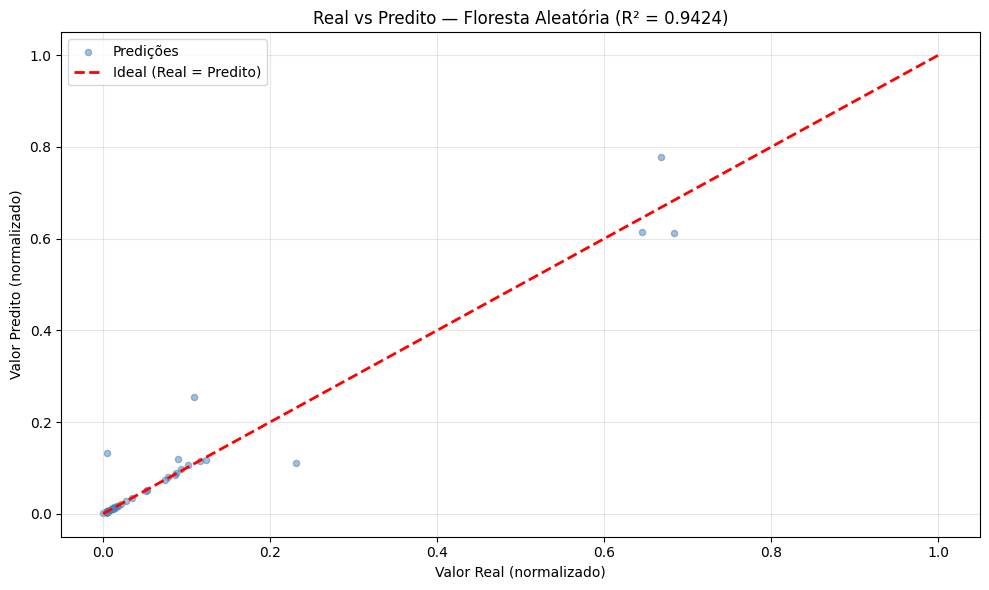

In [51]:
# Célula 15 — Gráfico Real vs Predito (melhor modelo)

melhor_nome = resultados.iloc[0]["nome"]

preds = {r["nome"]: r for r in todos_resultados}
y_pred_melhor = preds[melhor_nome]["y_pred"]

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_melhor, alpha=0.5, s=20, color="steelblue", label="Predições")
plt.plot([0, 1], [0, 1], "r--", linewidth=2, label="Ideal (Real = Predito)")
plt.xlabel("Valor Real (normalizado)")
plt.ylabel("Valor Predito (normalizado)")
plt.title(f"Real vs Predito — {melhor_nome} (R² = {resultados.iloc[0]['R2']:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

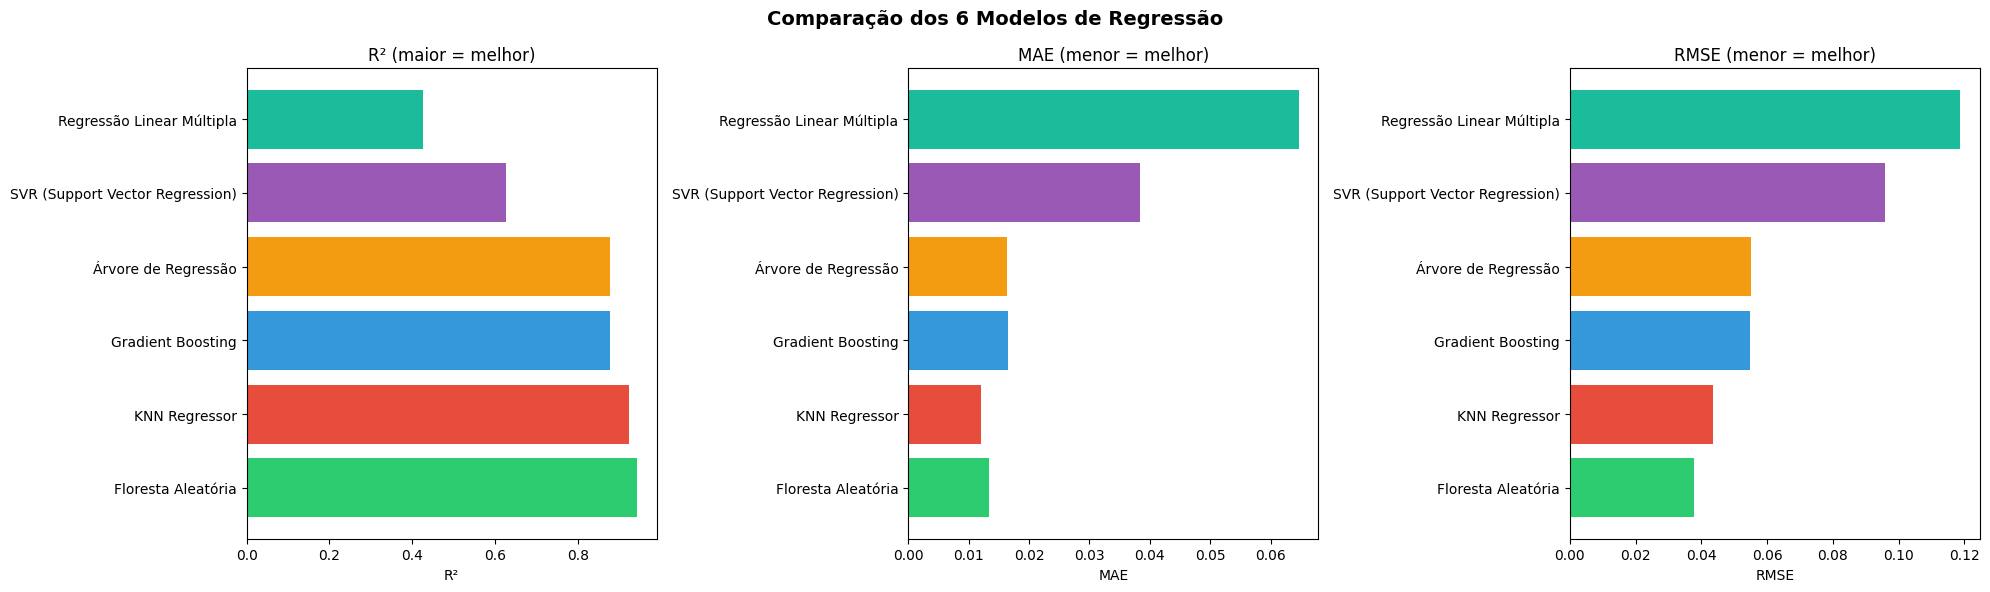

In [52]:
# Célula 16 — Gráfico de barras comparativo

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cores = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12", "#9b59b6", "#1abc9c"]

# R²
axes[0].barh(resultados["nome"], resultados["R2"], color=cores[:len(resultados)])
axes[0].set_xlabel("R²")
axes[0].set_title("R² (maior = melhor)")

# MAE
axes[1].barh(resultados["nome"], resultados["MAE"], color=cores[:len(resultados)])
axes[1].set_xlabel("MAE")
axes[1].set_title("MAE (menor = melhor)")

# RMSE
axes[2].barh(resultados["nome"], resultados["RMSE"], color=cores[:len(resultados)])
axes[2].set_xlabel("RMSE")
axes[2].set_title("RMSE (menor = melhor)")

plt.suptitle("Comparação dos 6 Modelos de Regressão", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [53]:
# Célula 17 — PROJEÇÕES FUTURAS: Preparação
'''
    OBJETIVO PRINCIPAL DO PROJETO:
    
    "Se nada mudar no cenário atual, como ficaria a emissão
    de CO2 daqui 10, 30, 50, 100, 300 e 500 anos?"
    
    Usamos o dataset TOTAL (emissão por ano) e treinamos
    vários modelos para projetar o futuro.
    
    Como temos apenas 1 feature (ano), adicionamos features
    polinomiais para capturar tendências não-lineares:
    - ano² (tendência quadrática)
    - ano³ (tendência cúbica)
'''

# Preparar dados para projeção
X_total = df_total[["ano"]].values
y_total = df_total["emissao_total"].values

# Adicionar features polinomiais (ano², ano³)
# Isso permite capturar tendências não-lineares
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_total)

print(f"Features originais: ano")
print(f"Features polinomiais: ano, ano², ano³")
print(f"X_poly shape: {X_poly.shape}")
print(f"Anos disponíveis: {df_total['ano'].min()} a {df_total['ano'].max()}")
print(f"\nDados de emissão total:")
print(df_total.tail(10))


Features originais: ano
Features polinomiais: ano, ano², ano³
X_poly shape: (50, 3)
Anos disponíveis: 1970 a 2019

Dados de emissão total:
     ano  emissao_total
40  2010   7.471605e+08
41  2011   7.356911e+08
42  2012   7.594675e+08
43  2013   1.008120e+09
44  2014   8.899871e+08
45  2015   9.422020e+08
46  2016   1.033447e+09
47  2017   9.231357e+08
48  2018   8.290037e+08
49  2019   1.314751e+09


In [55]:
# Célula 18 — PROJEÇÕES: Treinar todos os modelos
# ============================================================
'''
    Treinamos cada modelo com TODOS os dados históricos
    (sem split treino/teste) porque queremos a melhor
    projeção possível para o futuro.
    
    Depois avaliamos qual modelo se ajusta melhor aos
    dados históricos (R² no treino).
'''

# Definir anos futuros para projeção
ano_atual = df_total["ano"].max()
anos_projecao = [
    ano_atual + 10,   # ~2029
    ano_atual + 30,   # ~2049
    ano_atual + 50,   # ~2069
    ano_atual + 100,  # ~2119
    ano_atual + 300,  # ~2319
    ano_atual + 500,  # ~2519
]

print(f"Ano mais recente nos dados: {ano_atual}")
print(f"Anos para projeção: {anos_projecao}")

# Dicionário para guardar modelos e projeções
modelos_projecao = {}

# Lista de modelos para projeção
lista_modelos = [
    ("Regressão Linear", LinearRegression()),
    ("Árvore de Regressão", DecisionTreeRegressor(random_state=42, max_depth=5)),
    ("Floresta Aleatória", RandomForestRegressor(n_estimators=200, random_state=42)),
    ("SVR", SVR(kernel="rbf", C=100, epsilon=0.01, gamma="scale")),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)),
    ("KNN", KNeighborsRegressor(n_neighbors=3, weights="distance")),
]

print(f"\n{'='*60}")
print(f"  Treinando modelos para projeção...")
print(f"{'='*60}\n")

for nome, modelo in lista_modelos:
    # Treinar com TODOS os dados históricos
    modelo.fit(X_poly, y_total)
    
    # R² no treino (quão bem se ajusta aos dados históricos)
    y_pred_treino = modelo.predict(X_poly)
    r2_treino = r2_score(y_total, y_pred_treino)
    
    # Gerar projeções
    anos_futuros = np.array(anos_projecao).reshape(-1, 1)
    X_futuro_poly = poly.transform(anos_futuros)
    projecoes = modelo.predict(X_futuro_poly)
    
    # Guardar
    modelos_projecao[nome] = {
        "modelo": modelo,
        "r2_treino": r2_treino,
        "projecoes": projecoes,
    }
    
    print(f"  {nome:25s} | R² treino: {r2_treino:.6f}")

print(f"\nTodos os modelos treinados!")


Ano mais recente nos dados: 2019
Anos para projeção: [np.int64(2029), np.int64(2049), np.int64(2069), np.int64(2119), np.int64(2319), np.int64(2519)]

  Treinando modelos para projeção...

  Regressão Linear          | R² treino: 0.619955
  Árvore de Regressão       | R² treino: 0.991938
  Floresta Aleatória        | R² treino: 0.987293
  SVR                       | R² treino: -0.146457
  Gradient Boosting         | R² treino: 0.999999
  KNN                       | R² treino: 1.000000

Todos os modelos treinados!


In [56]:
# Célula 19 — PROJEÇÕES: Tabela comparativa
'''
    Tabela mostrando a projeção de cada modelo para cada
    horizonte temporal.
    
    Valores em TONELADAS de CO2.
'''

# Criar tabela de projeções
tabela = {"Ano": anos_projecao}
for nome, dados in modelos_projecao.items():
    tabela[nome] = dados["projecoes"]

df_projecoes = pd.DataFrame(tabela)

# Adicionar coluna de "daqui a X anos"
df_projecoes.insert(1, "Horizonte", [
    f"+{a - ano_atual} anos" for a in anos_projecao
])

print("->x<-" * 100)
print("  PROJEÇÕES DE EMISSÃO DE CO2 (toneladas) — SE NADA MUDAR")
print("->x<-" * 100)

# Formatar números grandes
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
print(df_projecoes.to_string(index=False))
pd.reset_option("display.float_format")

print("->x<-" * 100)

# Emissão atual para referência
emissao_atual = df_total[df_total["ano"] == ano_atual]["emissao_total"].values[0]
print(f"\nEmissão atual ({ano_atual}): {emissao_atual:,.0f} toneladas de CO2")


->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-
  PROJEÇÕES DE EMISSÃO DE CO2 (toneladas) — SE NADA MUDAR
->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<-->x<--

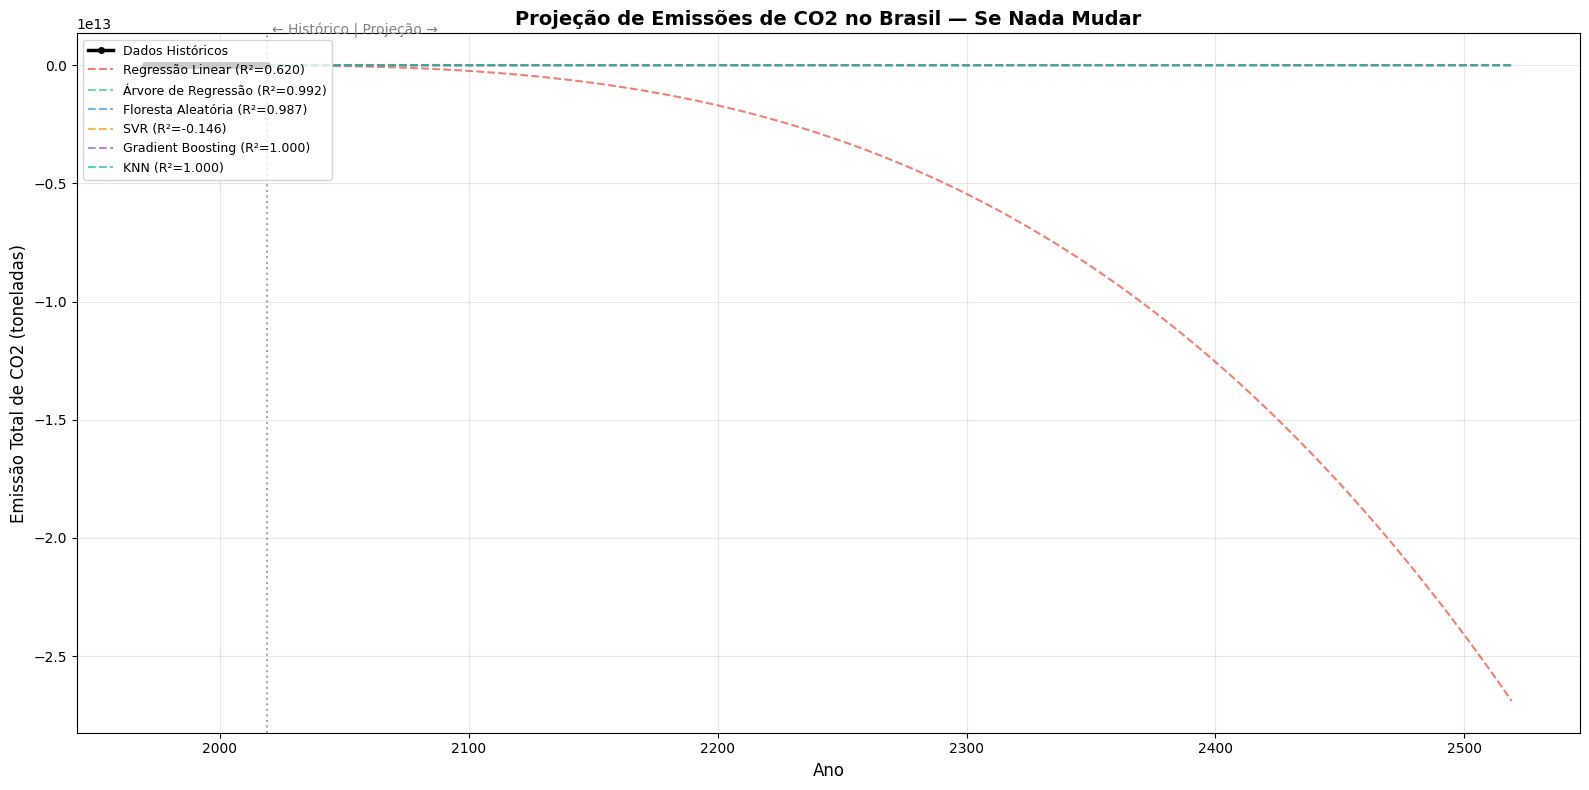

In [58]:
# Célula 20 — GRÁFICO 1: Histórico + Projeções (todos os modelos)
'''
    Gráfico principal: mostra os dados históricos reais
    e as projeções de cada modelo até o futuro.
'''

plt.figure(figsize=(16, 8))

# Dados históricos (linha preta grossa)
plt.plot(
    df_total["ano"], df_total["emissao_total"],
    "k-o", linewidth=2.5, markersize=4, label="Dados Históricos", zorder=5
)

# Gerar curvas suaves para cada modelo
anos_continuo = np.arange(df_total["ano"].min(), max(anos_projecao) + 1, 1).reshape(-1, 1)
X_continuo_poly = poly.transform(anos_continuo)

cores_modelos = {
    "Regressão Linear": "#e74c3c",
    "Árvore de Regressão": "#2ecc71",
    "Floresta Aleatória": "#3498db",
    "SVR": "#f39c12",
    "Gradient Boosting": "#9b59b6",
    "KNN": "#1abc9c",
}

for nome, dados in modelos_projecao.items():
    modelo = dados["modelo"]
    y_continuo = modelo.predict(X_continuo_poly)
    
    plt.plot(
        anos_continuo, y_continuo,
        "--", linewidth=1.5, alpha=0.7,
        color=cores_modelos[nome],
        label=f"{nome} (R²={dados['r2_treino']:.3f})"
    )

# Linha vertical separando histórico de projeção
plt.axvline(x=ano_atual, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
plt.text(ano_atual + 2, plt.ylim()[1] * 0.95, "← Histórico | Projeção →",
        fontsize=10, color="gray")

plt.xlabel("Ano", fontsize=12)
plt.ylabel("Emissão Total de CO2 (toneladas)", fontsize=12)
plt.title("Projeção de Emissões de CO2 no Brasil — Se Nada Mudar", fontsize=14, fontweight="bold")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


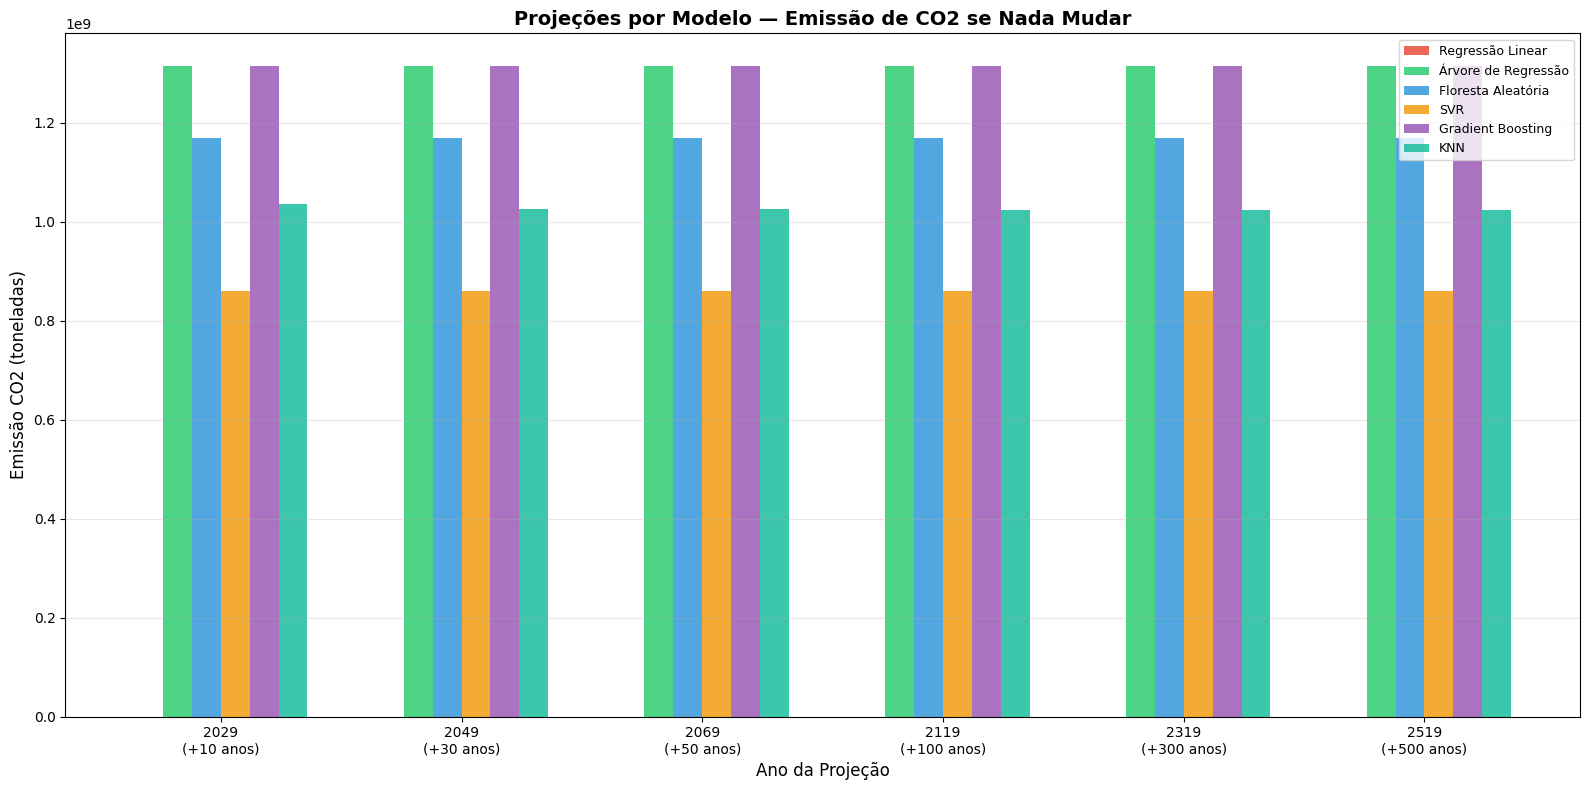

In [59]:
# Célula 21 — GRÁFICO 2: Projeções focado (apenas futuro)
'''
    Gráfico de barras agrupadas mostrando a projeção de cada
    modelo para cada horizonte temporal.
'''

fig, ax = plt.subplots(figsize=(16, 8))

n_modelos = len(modelos_projecao)
n_horizontes = len(anos_projecao)
largura = 0.12
x = np.arange(n_horizontes)

horizontes = [f"{a}\n(+{a - ano_atual} anos)" for a in anos_projecao]

for i, (nome, dados) in enumerate(modelos_projecao.items()):
    valores = dados["projecoes"]
    # Limitar valores negativos a zero (emissão não pode ser negativa)
    valores = np.maximum(valores, 0)
    
    ax.bar(
        x + i * largura,
        valores,
        largura,
        label=nome,
        color=list(cores_modelos.values())[i],
        alpha=0.85
    )

ax.set_xlabel("Ano da Projeção", fontsize=12)
ax.set_ylabel("Emissão CO2 (toneladas)", fontsize=12)
ax.set_title("Projeções por Modelo — Emissão de CO2 se Nada Mudar", fontsize=14, fontweight="bold")
ax.set_xticks(x + largura * (n_modelos - 1) / 2)
ax.set_xticklabels(horizontes)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


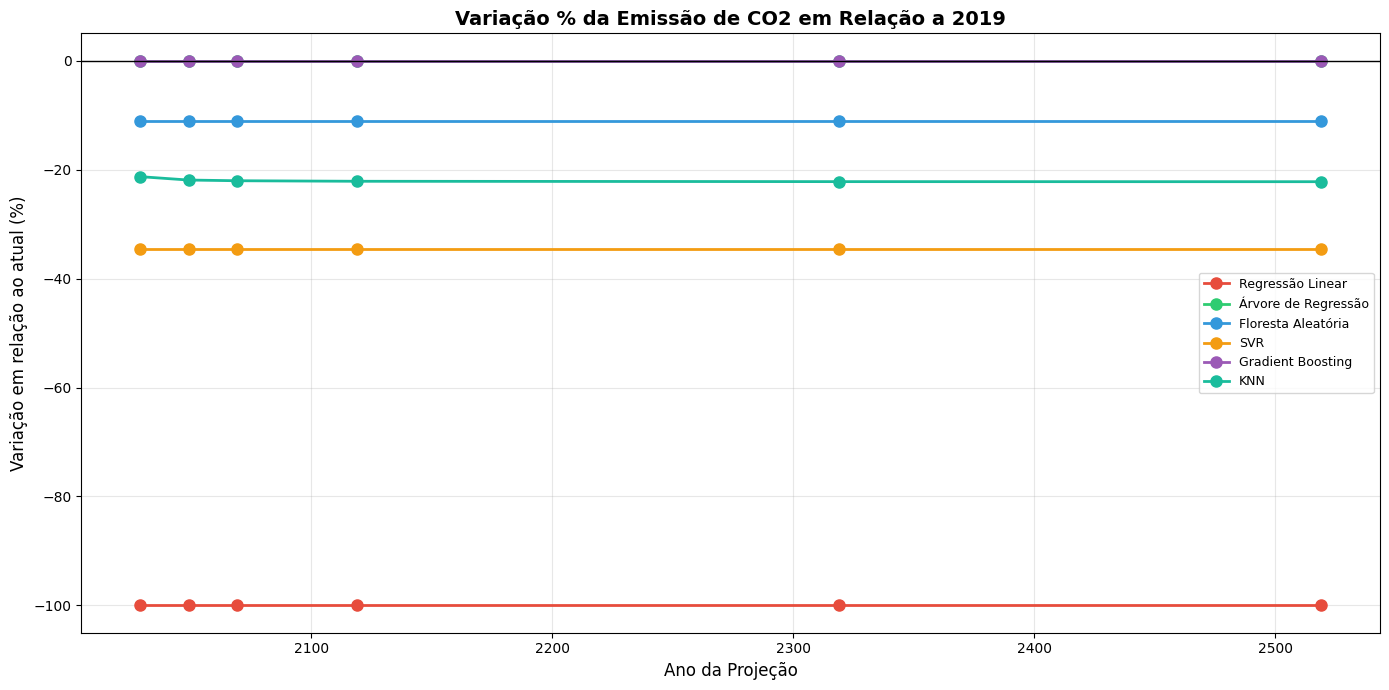

In [60]:
# Célula 22 — GRÁFICO 3: Variação percentual em relação ao atual
'''
    Mostra o AUMENTO PERCENTUAL da emissão em relação ao
    valor atual, facilitando a interpretação.
'''

emissao_atual = df_total[df_total["ano"] == ano_atual]["emissao_total"].values[0]

fig, ax = plt.subplots(figsize=(14, 7))

for nome, dados in modelos_projecao.items():
    projecoes = np.maximum(dados["projecoes"], 0)  # Sem negativos
    variacao_pct = ((projecoes - emissao_atual) / emissao_atual) * 100
    
    ax.plot(
        anos_projecao, variacao_pct,
        "-o", linewidth=2, markersize=8,
        color=cores_modelos[nome],
        label=nome
    )

ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("Ano da Projeção", fontsize=12)
ax.set_ylabel("Variação em relação ao atual (%)", fontsize=12)
ax.set_title(f"Variação % da Emissão de CO2 em Relação a {ano_atual}", fontsize=14, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ValueError: When stacked is True, each column must be either all positive or all negative. Column 'Agropecuária' contains both positive and negative values

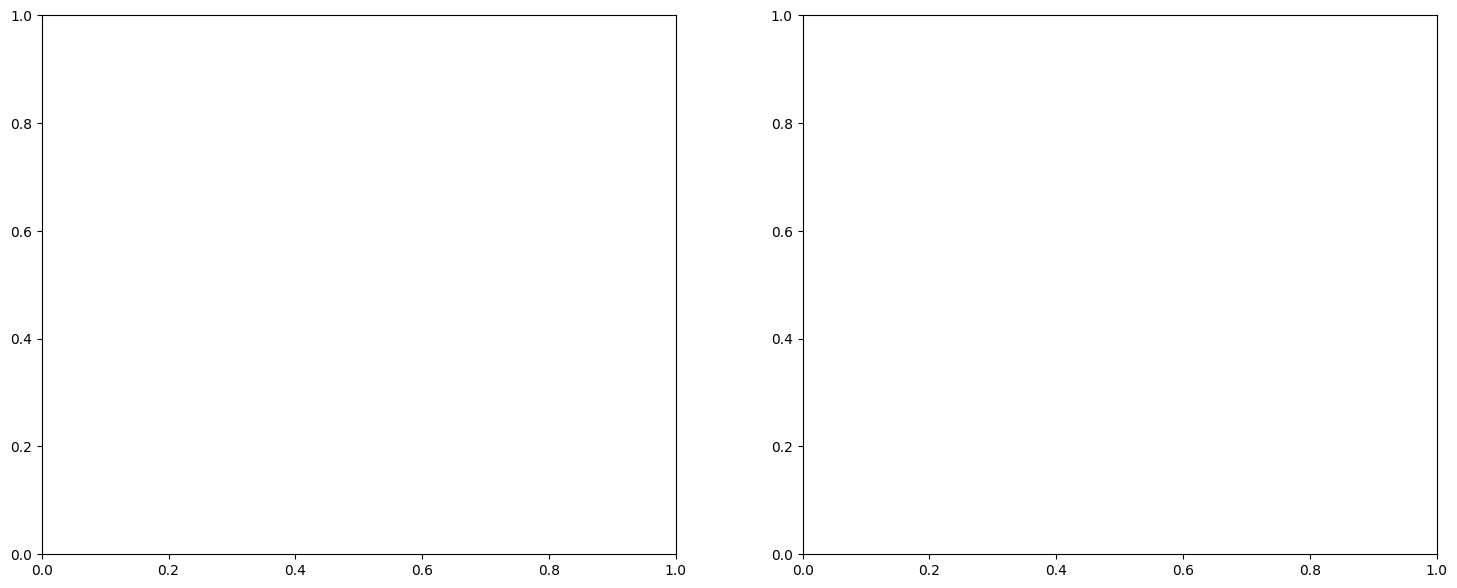

In [61]:
# Célula 23 — GRÁFICO 4: Emissão por SETOR — histórico
'''
    Mostra a contribuição de cada setor ao longo do tempo.
    Gráfico de área empilhada — permite ver qual setor
    contribui mais e como isso muda ao longo dos anos.
'''

# Pivotar dados por setor
df_pivot = df_setor.pivot_table(
    index="ano", columns="nivel_1", values="emissao", aggfunc="sum"
).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Área empilhada
df_pivot.plot.area(ax=axes[0], alpha=0.7, linewidth=0.5)
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Emissão CO2 (t)")
axes[0].set_title("Emissão de CO2 por Setor — Área Empilhada")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(True, alpha=0.3)

# Linhas separadas
for col in df_pivot.columns:
    axes[1].plot(df_pivot.index, df_pivot[col], "-o", markersize=3, label=col)

axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Emissão CO2 (t)")
axes[1].set_title("Emissão de CO2 por Setor — Linhas")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


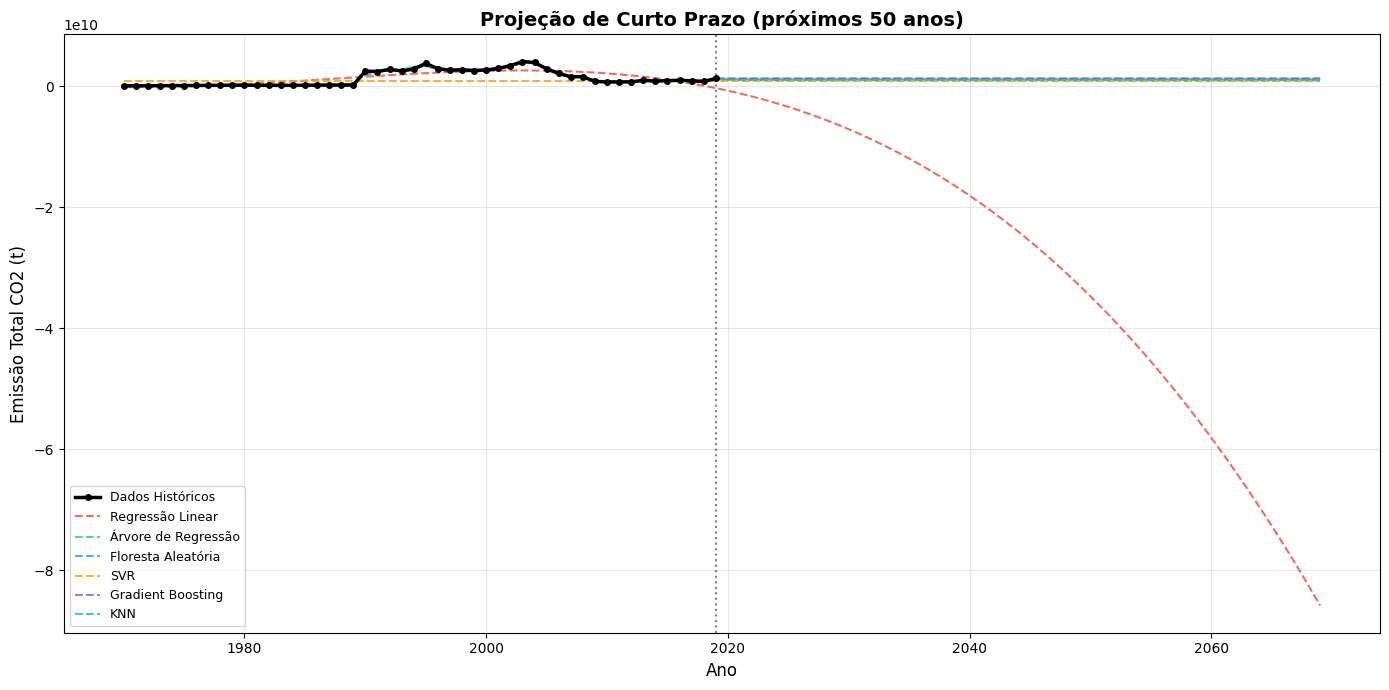

In [ ]:
# Célula 24 — GRÁFICO 5: Projeção curto prazo (próximos 50 anos)
'''
    Zoom nas projeções de curto prazo (mais confiáveis).
    Projeções muito distantes (300-500 anos) são especulativas.
'''

plt.figure(figsize=(14, 7))

# Histórico
plt.plot(
    df_total["ano"], df_total["emissao_total"],
    "k-o", linewidth=2.5, markersize=4, label="Dados Históricos", zorder=5
)

# Projeções apenas até +50 anos
anos_curto = np.arange(df_total["ano"].min(), ano_atual + 51, 1).reshape(-1, 1)
X_curto_poly = poly.transform(anos_curto)

for nome, dados in modelos_projecao.items():
    modelo = dados["modelo"]
    y_curto = modelo.predict(X_curto_poly)
    
    plt.plot(
        anos_curto, y_curto,
        "--", linewidth=1.5, alpha=0.8,
        color=cores_modelos[nome],
        label=f"{nome}"
    )

plt.axvline(x=ano_atual, color="gray", linestyle=":", linewidth=1.5)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Emissão Total CO2 (t)", fontsize=12)
plt.title("Projeção de Curto Prazo (próximos 50 anos)", fontsize=14, fontweight="bold")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Célula 25 — RESUMO FINAL DO PROJETO
'''
    Resumo consolidado de tudo que foi feito no projeto.
'''

print("=" * 70)
print("  RESUMO FINAL DO PROJETO")
print("  Análise e Projeção de Emissões de CO2 no Brasil")
print("=" * 70)

print(f"\n📁 DADOS:")
print(f"   Dataset: br_seeg_emissoes_brasil.csv")
print(f"   Registros originais: {df_raw.shape[0]:,}")
print(f"   Filtro aplicado: apenas CO2 (t)")
print(f"   Período: {df_total['ano'].min()} a {df_total['ano'].max()}")
print(f"   Emissão atual ({ano_atual}): {emissao_atual:,.0f} toneladas")

print(f"\n🔧 PRÉ-PROCESSAMENTO:")
print(f"   ✓ Verificação de valores nulos (NaN)")
print(f"   ✓ Remoção de NaN na coluna emissao")
print(f"   ✓ One-Hot Encoding (nivel_1 → dummies)")
print(f"   ✓ Normalização Min-Max [0, 1]")
print(f"   ✓ Agregação por ano e setor")

print(f"\n🤖 MODELOS DE REGRESSÃO (ranking por R²):")
print(resultados.to_string(index=False))

print(f"\n🔮 PROJEÇÕES (se nada mudar):")
for nome, dados in modelos_projecao.items():
    print(f"\n   {nome} (R² treino: {dados['r2_treino']:.4f}):")
    for i, ano in enumerate(anos_projecao):
        valor = max(dados["projecoes"][i], 0)
        variacao = ((valor - emissao_atual) / emissao_atual) * 100
        print(f"     {ano} (+{ano - ano_atual:3d} anos): {valor:>15,.0f} t  ({variacao:+.1f}%)")

print(f"\n{'='*70}")
print(f"  ⚠️  NOTA: Projeções assumem que tendências históricas se mantêm.")
print(f"  Fatores como políticas climáticas, tecnologia e desmatamento")
print(f"  podem alterar significativamente esses cenários.")
print(f"{'='*70}")

  RESUMO FINAL DO PROJETO
  Análise e Projeção de Emissões de CO2 no Brasil

📁 DADOS:
   Dataset: br_seeg_emissoes_brasil.csv
   Registros originais: 454,850
   Filtro aplicado: apenas CO2 (t)
   Período: 1970 a 2019
   Emissão atual (2019): 1,314,750,823 toneladas

🔧 PRÉ-PROCESSAMENTO:
   ✓ Verificação de valores nulos (NaN)
   ✓ Remoção de NaN na coluna emissao
   ✓ One-Hot Encoding (nivel_1 → dummies)
   ✓ Normalização Min-Max [0, 1]
   ✓ Agregação por ano e setor

🤖 MODELOS DE REGRESSÃO (ranking por R²):
                           nome      MAE     RMSE       R2
             Floresta Aleatória 0.013291 0.037629 0.942356
                  KNN Regressor 0.012101 0.043621 0.922536
              Gradient Boosting 0.016510 0.054834 0.877592
            Árvore de Regressão 0.016422 0.054950 0.877074
SVR (Support Vector Regression) 0.038338 0.095781 0.626521
      Regressão Linear Múltipla 0.064652 0.118798 0.425449

🔮 PROJEÇÕES (se nada mudar):

   Regressão Linear (R² treino: 0.6200):
 